In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

In [16]:
df = pd.read_csv("ab_test.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (404770, 3)


,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [17]:
print("Số người chơi:", df["user_id"].nunique(), "trên", len(df), "dòng")
print("Null:", df.isna().sum().sum())
print("Revenue âm:", (df["revenue"] < 0).sum())
print("tên nhóm:", df["testgroup"].unique())

Số người chơi: 404770 trên 404770 dòng
Null: 0
Revenue âm: 0
tên nhóm: ['b' 'a']


In [18]:
df["testgroup"] = df["testgroup"].replace({"a": "offer_a", "b": "offer_b"})
df["testgroup"].value_counts()

,count
testgroup,
offer_b,202667
offer_a,202103


In [19]:
df["revenue"].describe()

,revenue
count,"404,770.00"
mean,26.08
std,681.65
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,"37,433.00"


In [20]:
zeros = (df["revenue"] == 0).sum()

print(f"Người chơi không chi tiền : {zeros:,} ({zeros / len(df):.2%})")

Người chơi không chi tiền : 401,037 (99.08%)


In [21]:
payers = df[df["revenue"] > 0]

payers.groupby("testgroup")["revenue"].value_counts().groupby(level=0).head(5)

testgroup  revenue
offer_a    206        18
           310        18
           224        17
           265        17
           397        17
offer_b    2003        6
           3359        5
           2132        4
           2225        4
           2418        4
Name: count, dtype: int64

In [22]:
#conversion rate, ARPU, ARPPU
df["is_payer"] = df["revenue"] > 0
summary = df.groupby("testgroup").agg(
    players=("user_id", "count"),
    payers=("is_payer", "sum"),
    revenue=("revenue", "sum"),
)

summary["conversion_rate"] = summary["payers"] / summary["players"]
summary["arppu"] = summary["revenue"] / summary["payers"]
summary["arpu"] = summary["revenue"] / summary["players"]


summary

,players,payers,revenue,conversion_rate,arppu,arpu
testgroup,,,,,,
offer_a,202103,1928,5136189,0.01,"2,664.00",25.41
offer_b,202667,1805,5421603,0.01,"3,003.66",26.75


In [23]:
payers.groupby("testgroup")["revenue"].describe(percentiles=[0.5, 0.9])

,count,mean,std,min,50%,90%,max
testgroup,,,,,,,
offer_a,"1,928.00","2,664.00","9,049.04",200.00,311.00,393.30,"37,433.00"
offer_b,"1,805.00","3,003.66",572.62,"2,000.00","3,022.00","3,795.80","4,000.00"


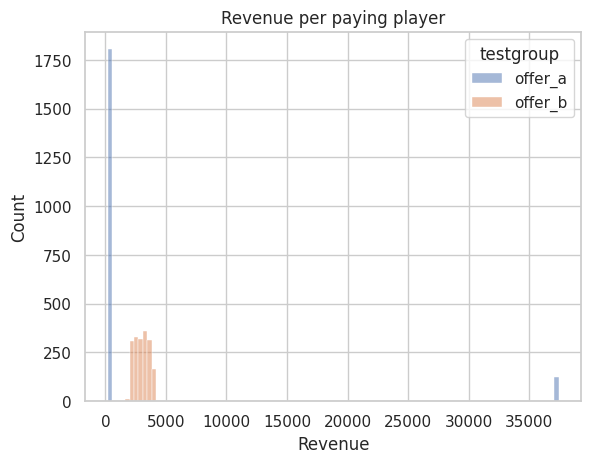

In [24]:
sns.histplot(data=payers, x="revenue", hue="testgroup")
plt.title("Revenue per paying player")
plt.xlabel("Revenue")

plt.savefig("revenue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()